In [1]:
"""
MOID Calculator - Function-based Implementation
Based on Wisniowski & Rickman (2013)
"Fast Geometric Method for Calculating Accurate Minimum Orbit Intersection Distances"

This implementation supports elliptical, parabolic, and hyperbolic orbits.
ENHANCED: Now includes true anomaly outputs at MOID configuration.
"""

import numpy as np
from typing import Tuple, List, Optional, Dict, Union


# Conversion constant
KM_TO_AU = 1.0 / 149597870.7  # km to AU

# ============================================================================
# COORDINATE TRANSFORMATIONS
# ============================================================================

def rotation_matrix_z(angle: float) -> np.ndarray:
    """Rotation matrix about z-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def rotation_matrix_x(angle: float) -> np.ndarray:
    """Rotation matrix about x-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rotate_to_reference_frame(orbit_A: Dict, orbit_B: Dict) -> Tuple[Dict, Dict]:
    """
    Rotate reference frame so orbit A lies in the reference plane.
    This is the preparation step described in Section 2.1 of the paper.
    
    Args:
        orbit_A: Dictionary with keys: a, e, i, omega, Omega
        orbit_B: Dictionary with keys: a, e, i, omega, Omega
        
    Returns:
        Tuple of (rotated_orbit_A, rotated_orbit_B)
    """
    # Orbit A becomes the reference plane
    new_A = {
        'a': orbit_A['a'],
        'e': orbit_A['e'],
        'i': 0.0,
        'omega': 0.0,
        'Omega': 0.0
    }
    
    # Rotation matrices
    R1 = rotation_matrix_z(-orbit_A['Omega'])
    R2 = rotation_matrix_x(-orbit_A['i'])
    R3 = rotation_matrix_z(-orbit_A['omega'])
    R_total = R3 @ R2 @ R1
    
    # Transform orbit B's pole vector
    pole_B = np.array([
        np.sin(orbit_B['Omega']) * np.sin(orbit_B['i']),
        -np.cos(orbit_B['Omega']) * np.sin(orbit_B['i']),
        np.cos(orbit_B['i'])
    ])
    pole_B_new = R_total @ pole_B
    i_new = np.arccos(np.clip(pole_B_new[2], -1, 1))
    
    # Calculate new Omega
    if np.abs(np.sin(i_new)) > 1e-10:
        Omega_new = np.arctan2(pole_B_new[0], -pole_B_new[1])
    else:
        Omega_new = 0.0
    
    # Transform perihelion direction
    peri_dir = np.array([
        np.cos(orbit_B['Omega']) * np.cos(orbit_B['omega']) - 
        np.sin(orbit_B['Omega']) * np.sin(orbit_B['omega']) * np.cos(orbit_B['i']),
        np.sin(orbit_B['Omega']) * np.cos(orbit_B['omega']) + 
        np.cos(orbit_B['Omega']) * np.sin(orbit_B['omega']) * np.cos(orbit_B['i']),
        np.sin(orbit_B['omega']) * np.sin(orbit_B['i'])
    ])
    peri_dir_new = R_total @ peri_dir
    
    # Calculate new omega
    if np.abs(np.sin(i_new)) > 1e-10:
        x_orb = peri_dir_new[0] * np.cos(Omega_new) + peri_dir_new[1] * np.sin(Omega_new)
        y_orb = (-peri_dir_new[0] * np.sin(Omega_new) + peri_dir_new[1] * np.cos(Omega_new)) / np.cos(i_new)
        omega_new = np.arctan2(y_orb, x_orb)
    else:
        omega_new = np.arctan2(peri_dir_new[1], peri_dir_new[0]) - Omega_new
    
    Omega_new = Omega_new % (2 * np.pi)
    omega_new = omega_new % (2 * np.pi)
    
    new_B = {
        'a': orbit_B['a'],
        'e': orbit_B['e'],
        'i': i_new,
        'omega': omega_new,
        'Omega': Omega_new
    }
    
    return new_A, new_B


# ============================================================================
# HELIOCENTRIC DISTANCE CALCULATIONS
# ============================================================================

def heliocentric_distance(a: float, e: float, true_anomaly: float) -> Optional[float]:
    """
    Calculate heliocentric distance for any conic section.
    Uses Eq. (1) from the paper for elliptical orbits.
    
    Args:
        a: Semi-major axis (negative for hyperbola)
        e: Eccentricity
        true_anomaly: True anomaly (radians)
        
    Returns:
        Heliocentric distance, or None if position doesn't exist
    """
    if e < 1.0:
        # Elliptical orbit - Eq. (1)
        return a * (1 - e**2) / (1 + e * np.cos(true_anomaly))
    elif abs(e - 1.0) < 1e-6:
        # Parabolic orbit
        q = a
        return q * (1 + e) / (1 + e * np.cos(true_anomaly))
    else:
        # Hyperbolic orbit
        max_true_anomaly = np.arccos(-1.0 / e)
        if abs(true_anomaly) > max_true_anomaly:
            return None
        return abs(a) * (e**2 - 1) / (1 + e * np.cos(true_anomaly))


def get_scan_range(e: float, hyperbolic_range: float = 6.0) -> Tuple[float, float]:
    """
    Get the scanning range based on orbit type.
    
    Args:
        e: Eccentricity
        hyperbolic_range: Range for hyperbolic orbits (radians)
        
    Returns:
        Tuple of (start_nu, end_nu)
    """
    if e < 1.0:
        return (0.0, 2 * np.pi)
    else:
        return (-hyperbolic_range, hyperbolic_range)


# ============================================================================
# CARTESIAN COORDINATES
# ============================================================================

def cartesian_coords_A(orbit_A: Dict, L: float) -> Optional[np.ndarray]:
    """
    Calculate Cartesian coordinates for object A (in reference plane).
    Object A lies in the reference plane (z=0) as per Section 2.1.
    Uses Eq. (5) for heliocentric distance.
    
    Args:
        orbit_A: Orbital elements dictionary
        L: Longitude (equals true anomaly for reference orbit)
        
    Returns:
        Position vector [x, y, z] or None if invalid
    """
    r = heliocentric_distance(orbit_A['a'], orbit_A['e'], L)
    if r is None:
        return None
    
    x = r * np.cos(L)
    y = r * np.sin(L)
    z = 0.0
    return np.array([x, y, z])


def cartesian_coords_B(orbit_B: Dict, nu: float) -> Optional[np.ndarray]:
    """
    Calculate Cartesian coordinates for object B.
    Uses Eq. (2) from the paper.
    
    Args:
        orbit_B: Orbital elements dictionary
        nu: True anomaly
        
    Returns:
        Position vector [x, y, z] or None if invalid
    """
    r = heliocentric_distance(orbit_B['a'], orbit_B['e'], nu)
    if r is None:
        return None
    
    cos_Om = np.cos(orbit_B['Omega'])
    sin_Om = np.sin(orbit_B['Omega'])
    cos_om_nu = np.cos(orbit_B['omega'] + nu)
    sin_om_nu = np.sin(orbit_B['omega'] + nu)
    cos_i = np.cos(orbit_B['i'])
    sin_i = np.sin(orbit_B['i'])
    
    # Eq. (2)
    x = r * (cos_Om * cos_om_nu - sin_Om * sin_om_nu * cos_i)
    y = r * (sin_Om * cos_om_nu + cos_Om * sin_om_nu * cos_i)
    z = r * sin_om_nu * sin_i
    
    return np.array([x, y, z])

def orbital_period(a):
    """Orbital period in days."""
    return 2*np.pi / np.sqrt(mu_sun / a**3)

# ============================================================================
# MERIDIONAL PLANE SCANNING (Section 2.2)
# ============================================================================

def meridional_distance(orbit_A: Dict, orbit_B: Dict, nu: float) -> Optional[Tuple[float, float, np.ndarray, np.ndarray]]:
    """
    Calculate meridional distance for a given true anomaly of object B.
    This implements the geometry shown in Figures 1 and 2 of the paper.
    
    The meridional plane is perpendicular to orbit A and contains object B.
    Uses Eq. (3)-(6) from the paper.
    
    Args:
        orbit_A: Orbital elements of object A
        orbit_B: Orbital elements of object B
        nu: True anomaly of object B
        
    Returns:
        Tuple of (distance, longitude_A, pos_A, pos_B) or None if invalid
    """
    # Get position of B - Eq. (2)
    pos_B = cartesian_coords_B(orbit_B, nu)
    if pos_B is None:
        return None
    
    # Calculate longitude L from B's position - Eq. (3), (4)
    rho_B = np.sqrt(pos_B[0]**2 + pos_B[1]**2)
    L = np.arctan2(pos_B[1], pos_B[0])
    
    # Get position of A at this longitude - Eq. (5)
    pos_A = cartesian_coords_A(orbit_A, L)
    if pos_A is None:
        return None
    
    # Calculate meridional distance - Eq. (6)
    # D = sqrt(z_B^2 + (rho_B - r_A)^2)
    r_A = np.linalg.norm(pos_A[:2])
    D = np.sqrt(pos_B[2]**2 + (rho_B - r_A)**2)
    
    return D, L, pos_A, pos_B


def scan_orbits(orbit_A: Dict, orbit_B: Dict, scan_step: float = 0.12, 
                hyperbolic_range: float = 6.0) -> List[Tuple[float, float, float, np.ndarray, np.ndarray]]:
    """
    Scan orbits to find local minima using meridional plane method.
    This implements Section 2.2 of the paper.
    
    The scan_step of 0.12 rad is optimal as stated in the paper:
    "we have found that a scanning step of 0.12 rad is close to optimal"
    
    Args:
        orbit_A: Orbital elements of object A
        orbit_B: Orbital elements of object B
        scan_step: Step size in radians (default 0.12 rad from paper)
        hyperbolic_range: Range for hyperbolic orbits
        
    Returns:
        List of minima as (distance, nu, L, pos_A, pos_B)
    """
    minima = []
    
    # Get scan range based on orbit type
    start_nu, end_nu = get_scan_range(orbit_B['e'], hyperbolic_range)
    
    nu_values = np.arange(start_nu, end_nu, scan_step)
    distances = []
    positions_A = []
    positions_B = []
    L_values = []
    valid_indices = []
    
    # Scan through true anomaly values
    for idx, nu in enumerate(nu_values):
        result = meridional_distance(orbit_A, orbit_B, nu)
        if result is not None:
            D, L, pos_A, pos_B = result
            distances.append(D)
            L_values.append(L)
            positions_A.append(pos_A)
            positions_B.append(pos_B)
            valid_indices.append(idx)
    
    if len(distances) < 3:
        return minima
    
    # Find local minima
    distances = np.array(distances)
    for i in range(1, len(distances) - 1):
        if distances[i] < distances[i-1] and distances[i] < distances[i+1]:
            original_idx = valid_indices[i]
            minima.append((
                distances[i],
                nu_values[original_idx],
                L_values[i],
                positions_A[i],
                positions_B[i]
            ))
    
    # For elliptical orbits, check periodic boundary
    if orbit_B['e'] < 1.0 and len(distances) > 2:
        if distances[0] < distances[1] and distances[0] < distances[-1]:
            minima.append((
                distances[0],
                nu_values[valid_indices[0]],
                L_values[0],
                positions_A[0],
                positions_B[0]
            ))
    
    return minima


# ============================================================================
# PARALLEL TUNING (Section 2.3)
# ============================================================================

def parallel_tune(orbit_A: Dict, orbit_B: Dict, L_init: float, nu_init: float,
                 initial_step: float = 0.06, tune_factor: float = 0.15,
                 target_step: float = 5e-6) -> Tuple[float, float, float]:
    """
    Perform parallel tuning to zoom in on minimum distance.
    This implements the method described in Section 2.3 and illustrated in Figure 3.
    
    The parameters are from the paper:
    - Initial step: 0.06 rad
    - Tune factor: 0.15 (step size multiplier)
    - Target step: 5e-6 rad for initial tuning, 1e-14 rad for final tuning
    
    Args:
        orbit_A: Orbital elements of object A
        orbit_B: Orbital elements of object B
        L_init: Initial longitude for object A
        nu_init: Initial true anomaly for object B
        initial_step: Initial step size (default 0.06 rad from paper)
        tune_factor: Factor to decrease step (default 0.15 from paper)
        target_step: Target step size to reach
        
    Returns:
        Tuple of (final_distance, final_L, final_nu)
    """
    L = L_init
    nu = nu_init
    step = initial_step
    
    while step > target_step:
        improved = True
        while improved:
            improved = False
            
            best_dist_sq = np.inf
            best_L = L
            best_nu = nu
            
            # Test 9 positions (3x3 grid)
            for dL in [-step, 0, step]:
                for dnu in [-step, 0, step]:
                    L_test = L + dL
                    nu_test = nu + dnu
                    
                    pos_A = cartesian_coords_A(orbit_A, L_test)
                    pos_B = cartesian_coords_B(orbit_B, nu_test)
                    
                    if pos_A is None or pos_B is None:
                        continue
                    
                    # Use squared distance to avoid sqrt
                    dist_sq = np.sum((pos_A - pos_B)**2)
                    
                    if dist_sq < best_dist_sq:
                        best_dist_sq = dist_sq
                        best_L = L_test
                        best_nu = nu_test
            
            if best_L != L or best_nu != nu:
                L = best_L
                nu = best_nu
                improved = True
        
        # Decrease step size by tune factor
        step *= tune_factor
    
    # Calculate final distance
    pos_A = cartesian_coords_A(orbit_A, L)
    pos_B = cartesian_coords_B(orbit_B, nu)
    
    if pos_A is None or pos_B is None:
        return np.inf, L, nu
    
    final_dist = np.linalg.norm(pos_A - pos_B)
    return final_dist, L, nu


# ============================================================================
# MAIN MOID CALCULATION (Section 2.4)
# ============================================================================

def calculate_moid(orbit_A: Dict, orbit_B: Dict, 
                  scan_step: float = 0.12,
                  initial_tune_step: float = 0.06,
                  tune_factor: float = 0.15,
                  initial_target_step: float = 5e-6,
                  final_target_step: float = 1e-14,
                  hyperbolic_range: float = 6.0,
                  use_safety: bool = True,
                  return_anomalies: bool = False) -> Union[float, Tuple[float, float, float]]:
    """
    Calculate MOID between two orbits using Wisniowski & Rickman (2013) method.
    
    This implements the complete algorithm described in Section 2.4 of the paper,
    including the safety measures against missing MOIDs.
    
    Parameters from the paper:
    - scan_step: 0.12 rad (optimal as stated in paper)
    - initial_tune_step: 0.06 rad
    - tune_factor: 0.15
    - initial_target_step: 5×10^-6 rad
    - final_target_step: 1×10^-14 rad (double precision limit)
    
    Args:
        orbit_A: Dictionary with keys: a, e, i, omega, Omega
        orbit_B: Dictionary with keys: a, e, i, omega, Omega
        scan_step: Meridional scanning step (default 0.12 rad from paper)
        initial_tune_step: Initial tuning step (default 0.06 rad from paper)
        tune_factor: Step reduction factor (default 0.15 from paper)
        initial_target_step: Initial tuning target (default 5e-6 rad from paper)
        final_target_step: Final tuning target (default 1e-14 rad from paper)
        hyperbolic_range: Scan range for hyperbolic orbits (default 6.0 rad)
        use_safety: Use safety measure for invisible minima (default True)
        return_anomalies: If True, return (MOID, L_A, nu_B) instead of just MOID
        
    Returns:
        If return_anomalies is False:
            MOID in same units as semi-major axis
        If return_anomalies is True:
            Tuple of (MOID, L_A, nu_B) where:
                - MOID: minimum distance in same units as semi-major axis
                - L_A: true anomaly/longitude of object A at MOID (radians)
                - nu_B: true anomaly of object B at MOID (radians)
    """
    # Step 1: Rotate to reference frame (Section 2.1)
    orbit_A_rot, orbit_B_rot = rotate_to_reference_frame(orbit_A, orbit_B)
    
    # Step 2: Scan for minima (Section 2.2)
    minima = scan_orbits(orbit_A_rot, orbit_B_rot, scan_step, hyperbolic_range)
    
    # Step 3: Handle special cases (Section 2.4)
    # Case 1: Only one minimum detected - risk of invisible minimum
    if len(minima) == 1 and use_safety:
        moid_candidates = []
        anomaly_candidates = []
        
        # Use 4 starting points as safety measure
        if orbit_B_rot['e'] >= 1.0:
            max_nu = min(hyperbolic_range,
                        np.arccos(-1.0/orbit_B_rot['e']) - 0.1 if orbit_B_rot['e'] > 1 else hyperbolic_range)
            test_points = np.linspace(-max_nu, max_nu, 4)
        else:
            test_points = [i * np.pi / 2 for i in range(4)]
        
        for nu_start in test_points:
            result = meridional_distance(orbit_A_rot, orbit_B_rot, nu_start)
            if result is None:
                continue
            
            D, L, pos_A, pos_B = result
            
            # Initial tuning
            dist_initial, L_tune, nu_tune = parallel_tune(
                orbit_A_rot, orbit_B_rot, L, nu_start,
                initial_tune_step, tune_factor, initial_target_step
            )
            
            # Final tuning
            dist_final, L_final, nu_final = parallel_tune(
                orbit_A_rot, orbit_B_rot, L_tune, nu_tune,
                initial_tune_step, tune_factor, final_target_step
            )
            
            if dist_final < np.inf:
                moid_candidates.append(dist_final)
                anomaly_candidates.append((L_final, nu_final))
        
        if moid_candidates:
            min_idx = np.argmin(moid_candidates)
            moid = moid_candidates[min_idx]
            L_A, nu_B = anomaly_candidates[min_idx]
            return (moid, L_A, nu_B) if return_anomalies else moid
        else:
            return (np.inf, 0.0, 0.0) if return_anomalies else np.inf
    
    # Case 2: Indistinguishable minima - use safety procedure
    if len(minima) >= 2 and use_safety:
        sorted_minima = sorted(minima, key=lambda x: x[0])
        if len(sorted_minima) >= 2:
            diff = abs(sorted_minima[0][0] - sorted_minima[1][0])
            if diff < 1e-6:
                # Use 4 starting points
                moid_candidates = []
                anomaly_candidates = []
                
                if orbit_B_rot['e'] >= 1.0:
                    max_nu = min(hyperbolic_range,
                                np.arccos(-1.0/orbit_B_rot['e']) - 0.1 if orbit_B_rot['e'] > 1 else hyperbolic_range)
                    test_points = np.linspace(-max_nu, max_nu, 4)
                else:
                    test_points = [i * np.pi / 2 for i in range(4)]
                
                for nu_start in test_points:
                    result = meridional_distance(orbit_A_rot, orbit_B_rot, nu_start)
                    if result is None:
                        continue
                    
                    D, L, pos_A, pos_B = result
                    
                    dist_initial, L_tune, nu_tune = parallel_tune(
                        orbit_A_rot, orbit_B_rot, L, nu_start,
                        initial_tune_step, tune_factor, initial_target_step
                    )
                    
                    dist_final, L_final, nu_final = parallel_tune(
                        orbit_A_rot, orbit_B_rot, L_tune, nu_tune,
                        initial_tune_step, tune_factor, final_target_step
                    )
                    
                    if dist_final < np.inf:
                        moid_candidates.append(dist_final)
                        anomaly_candidates.append((L_final, nu_final))
                
                if moid_candidates:
                    min_idx = np.argmin(moid_candidates)
                    moid = moid_candidates[min_idx]
                    L_A, nu_B = anomaly_candidates[min_idx]
                    return (moid, L_A, nu_B) if return_anomalies else moid
                else:
                    return (np.inf, 0.0, 0.0) if return_anomalies else np.inf
    
    # Case 3: Normal case - tune each detected minimum
    moid_candidates = []
    anomaly_candidates = []
    for D_min, nu, L, pos_A, pos_B in minima:
        # Initial tuning
        dist_initial, L_tune, nu_tune = parallel_tune(
            orbit_A_rot, orbit_B_rot, L, nu,
            initial_tune_step, tune_factor, initial_target_step
        )
        
        # Final tuning
        dist_final, L_final, nu_final = parallel_tune(
            orbit_A_rot, orbit_B_rot, L_tune, nu_tune,
            initial_tune_step, tune_factor, final_target_step
        )
        
        if dist_final < np.inf:
            moid_candidates.append(dist_final)
            anomaly_candidates.append((L_final, nu_final))
    
    # Return the smallest MOID
    if moid_candidates:
        min_idx = np.argmin(moid_candidates)
        moid = moid_candidates[min_idx]
        L_A, nu_B = anomaly_candidates[min_idx]
        return (moid, L_A, nu_B) if return_anomalies else moid
    else:
        # Fallback: brute force search
        start_nu, end_nu = get_scan_range(orbit_B_rot['e'], hyperbolic_range)
        nu_values = np.linspace(start_nu, end_nu, 1000)
        distances = []
        anomalies = []
        for nu in nu_values:
            result = meridional_distance(orbit_A_rot, orbit_B_rot, nu)
            if result is not None:
                distances.append(result[0])
                anomalies.append((result[1], nu))
        
        if distances:
            min_idx = np.argmin(distances)
            moid = distances[min_idx]
            L_A, nu_B = anomalies[min_idx]
            return (moid, L_A, nu_B) if return_anomalies else moid
        else:
            return (np.inf, 0.0, 0.0) if return_anomalies else np.inf


# ============================================================================
# CONVENIENCE FUNCTIONS
# ============================================================================

def create_orbit(q: float, e: float, i: float, omega: float, Omega: float,M: float,
                use_degrees: bool = True) -> Dict:
    """
    Create an orbit dictionary.
    
    Args:
        a: Semi-major axis (AU)
        e: Eccentricity
        i: Inclination (degrees or radians)
        omega: Argument of perihelion (degrees or radians)
        Omega: Longitude of ascending node (degrees or radians)
        use_degrees: Whether angles are in degrees (default True)
        
    Returns:
        Dictionary with orbital elements in radians
    """
    if use_degrees:
        i = np.radians(i)
        omega = np.radians(omega)
        Omega = np.radians(Omega)
        
    a = get_semimajor(q, e)
    
    return {
        'a': a,
        'q': q,
        'e': e,
        'i': i,
        'omega': omega,
        'Omega': Omega,
        'M':M,
    }


def get_orbit_type(e: float) -> str:
    """Return orbit type as string."""
    if e < 1.0:
        return "elliptical"
    elif abs(e - 1.0) < 1e-6:
        return "parabolic"
    else:
        return "hyperbolic"


    
def get_semimajor(q: float, e: float) ->float:
    if e < 1.0:
        return q / (1-e)

    
def true_to_mean(f: float, e: float) -> float:
    """
    Convert true anomaly (f) to mean anomaly (M)
    for an elliptical orbit (0 <= e < 1).

    Parameters
    ----------
    f : float
        True anomaly [radians]
    e : float
        Eccentricity

    Returns
    -------
    M : float
        Mean anomaly [radians]
    """
    # True anomaly -> Eccentric anomaly
    E = 2 * np.arctan2(
        np.sqrt(1 - e) * np.sin(f / 2),
        np.sqrt(1 + e) * np.cos(f / 2)
    )

    # Eccentric anomaly -> Mean anomaly
    M = E - e * np.sin(E)

    return M

mu_sun = 1.32712 * (10**11)* (KM_TO_AU**3) * (86400**2)

def time_period(init_M, target_f, target_e, target_a):
    target_M = true_to_mean(target_f, target_e) % (2 * np.pi)
    init_M = init_M % (2 * np.pi)
    delM = (target_M - init_M) % (2 * np.pi)
    n = np.sqrt(mu_sun / target_a**3)
    return delM / n
    
# ============================================================================
# EXAMPLE USAGE
# ============================================================================


def test_final_cases():
    """
    Calculate MOIDs for the 4 requested cases:
    1. Earth - Apophis
    2. Earth - 2024 YR4
    3. Apophis - 2024 YR4
    4. Earth - 3I/ATLAS (hyperbolic)
    """
    
    print("\n" + "="*90)
    print("FINAL MOID CALCULATIONS - 4 REQUESTED CASES")
    print("Wisniowski & Rickman (2013) Method - Function-based Implementation")
    print("="*90)
    
    # Define orbital elements (converting from km to AU)
    orbits_data = {
        "Earth": {
            "q": 9.78969676e-01,
            "e": 1.83889630e-02,
            "i": 7.55697209e-05,
            "omega": 5.34322623,
            "Omega": 2.63906227,
            "M":1.88972281,
        },
        "FI2026": {
            "q": 0.74161536,
            "e": 0.19293483,
            "i": 0.05877868,
            "omega": 2.22509624,
            "Omega": 3.55784498,
            "M":3.64624167,
        },
    }
    
    # Create orbit dictionaries
    orbits = {}
    for name, data in orbits_data.items():
        orbits[name] = create_orbit(
            q=data['q'],
            e=data['e'],
            i=data['i'],
            omega=data['omega'],
            Omega=data['Omega'],
            M=data['M'],
            use_degrees=False
        )
    
    # Display orbital information
    print("\nORBITAL ELEMENTS:")
    print("-"*90)
    for name, orbit in orbits.items():
        orbit_type = get_orbit_type(orbit['e'])
        
        print(f"\n{name}:")
        print(f"  Orbit type:      {orbit_type}")
        print(f"  Semi-major axis: a = {orbit['a']:12.6f} AU")
        print(f"  Eccentricity:    e = {orbit['e']:12.6f}")
        print(f"  Perihelion:      q = {orbit['q']:12.6f} AU")
        print(f"  Inclination:     i = {np.degrees(orbit['i']):12.6f}°")
        print(f"  Arg. perihelion: ω = {np.degrees(orbit['omega']):12.6f}°")
        print(f"  Long. asc. node: Ω = {np.degrees(orbit['Omega']):12.6f}°")
    
    # Define the test cases
    test_cases = [
        ("Earth", "FI2026"),
    ]
    
    # Calculate MOIDs
    print("\n" + "="*90)
    print("MOID RESULTS:")
    print("="*90)
    print(f"\n{'Case':<4} {'Object 1':<15} {'Object 2':<15} {'MOID (AU)':<18} {'MOID (km)':<20} {'Status':<20}")
    print("-"*90)
    
    PHA_THRESHOLD = 0.01  # AU
    
    results = []
    for idx, (name1, name2) in enumerate(test_cases, 1):
        orbit1 = orbits[name1]
        orbit2 = orbits[name2]
        
        # Calculate MOID with anomalies
        moid_au, L_A, nu_B = calculate_moid(orbit1, orbit2, return_anomalies=True)
        
        if moid_au < np.inf:
            moid_km = moid_au / KM_TO_AU
            
            # Determine status
            if name1 == "Earth" and moid_au < PHA_THRESHOLD:
                status = "⚠️  POTENTIALLY HAZARDOUS"
            elif name1 == "Earth" and moid_au < 0.20:
                status = "Close approach"
            else:
                status = "Safe"
            
            print(f"{idx:<4} {name1:<15} {name2:<15} {moid_au:<18.10f} {moid_km:<20,.1f} {status:<20}")
            results.append((name1, name2, moid_au, moid_km, status, L_A, nu_B))
        else:
            print(f"{idx:<4} {name1:<15} {name2:<15} {'INFINITE':<18} {'No intersection':<20} {'N/A':<20}")
            results.append((name1, name2, np.inf, np.inf, 'N/A', 0.0, 0.0))
    
    # Detailed analysis
    print("\n" + "="*90)
    print("DETAILED ANALYSIS:")
    print("="*90)
    
    for idx, (name1, name2) in enumerate(test_cases, 1):
        orbit1 = orbits[name1]
        orbit2 = orbits[name2]
        moid_au = results[idx-1][2]
        L_A = results[idx-1][5]
        nu_B = results[idx-1][6]
        
        print(f"\nCase {idx}: {name1} - {name2}")
        print("-"*90)
        
        if moid_au < np.inf:
            moid_km = moid_au / KM_TO_AU
            moid_million_km = moid_km / 1e6
            earth_radii = moid_km / 6371.0  # Earth radius
            
            print(f"  MOID = {moid_au:.10f} AU")
            print(f"  MOID = {moid_km:,.2f} km")
            print(f"  MOID = {moid_million_km:.4f} million km")
            print(f"  MOID = {earth_radii:,.1f} Earth radii")
            
            # NEW: Display anomalies at MOID
            print(f"\n  TRUE ANOMALIES AT MOID CONFIGURATION:")
            print(f"  {name1} true anomaly:  f₁ = {np.degrees(L_A):10.4f}° ({L_A:10.6f} rad)")
            print(f"  {name2} true anomaly:  f₂ = {np.degrees(nu_B):10.4f}° ({nu_B:10.6f} rad)")
            
            T_earth = orbital_period(orbit1['a'])  
            T_fi    = orbital_period(orbit2['a'])     

            t_earth = time_period(orbit1['M'], L_A , orbit1['e'], orbit1['a'])
            t_fi    = time_period(orbit2['M'],   nu_B , orbit2['e'],   orbit2['a'])

            print(f"Earth first arrival:  {t_earth} days")
            print(f"FI2026 first arrival: {t_fi} days")
            print(f"Earth period:         {T_earth} days")
            print(f"FI2026 period:        {T_fi} days")

            earth_revs = 0
            fi_revs    = 0

            while abs(t_fi - t_earth) > 1.0:
                if t_fi < t_earth:
                    t_fi    += T_fi
                    fi_revs += 1
                else:
                    t_earth    += T_earth
                    earth_revs += 1

            print(f"\nRevolutions added to match:")
            print(f"  Earth  : {earth_revs} extra revolution(s)  → arrives at t = {t_earth} days")
            print(f"  FI2026 : {fi_revs} extra revolution(s)  → arrives at t = {t_fi} days")
            print(f"\n  Impact time: ~{min(t_fi, t_earth)} days")
            
            if name1 == "Earth":
                if moid_au < PHA_THRESHOLD:
                    print(f"\n  ⚠️  CLASSIFICATION: Potentially Hazardous Asteroid (PHA)")
                    print(f"  ⚠️  MOID is below the {PHA_THRESHOLD} AU threshold")
                else:
                    print(f"\n  ✓ CLASSIFICATION: Not a PHA (MOID > {PHA_THRESHOLD} AU)")
            
            # Additional context for hyperbolic case
            if get_orbit_type(orbit2['e']) == "hyperbolic":
                print(f"\n  Note: {name2} is on a hyperbolic trajectory (interstellar object)")
        else:
            print(f"  No intersection possible (infinite MOID)")
    
    print("\n" + "="*90 + "\n")


if __name__ == "__main__":
    test_final_cases()


FINAL MOID CALCULATIONS - 4 REQUESTED CASES
Wisniowski & Rickman (2013) Method - Function-based Implementation

ORBITAL ELEMENTS:
------------------------------------------------------------------------------------------

Earth:
  Orbit type:      elliptical
  Semi-major axis: a =     0.997309 AU
  Eccentricity:    e =     0.018389
  Perihelion:      q =     0.978970 AU
  Inclination:     i =     0.004330°
  Arg. perihelion: ω =   306.144312°
  Long. asc. node: Ω =   151.207130°

FI2026:
  Orbit type:      elliptical
  Semi-major axis: a =     0.918904 AU
  Eccentricity:    e =     0.192935
  Perihelion:      q =     0.741615 AU
  Inclination:     i =     3.367770°
  Arg. perihelion: ω =   127.488624°
  Long. asc. node: Ω =   203.849502°

MOID RESULTS:

Case Object 1        Object 2        MOID (AU)          MOID (km)            Status              
------------------------------------------------------------------------------------------
1    Earth           FI2026          0.0000000

Part 2: Öpik B-Plane Results
  U∞                 = 5.8989 km/s
  v_esc (Earth)      = 11.1861 km/s
  ξ                  = +0.1625 km
  ζ                  = +0.9907 km
  |b|                = 1.0040 km  (0.000158 R⊕)
  b_coll             = 13658.39 km  (2.1438 R⊕)
  θ (u∞ ∠ V_Earth)   = 110.29°
  Impact confirmed:    |b| << b_coll → DIRECT HIT


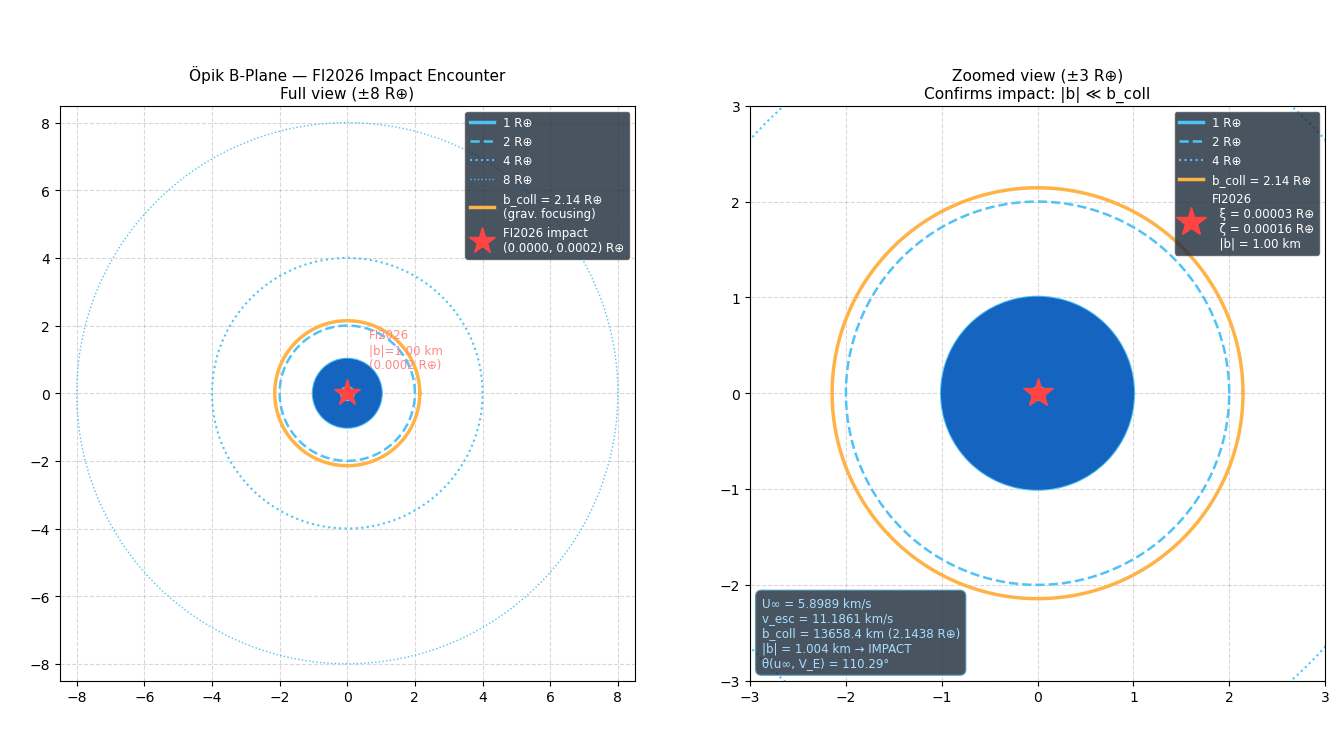


Figure saved to: ./hw2_part2_bplane.png


In [2]:
"""
AE 498 HW2 — Part 2 only
Öpik b-plane visualization of FI2026 impact encounter
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyArrowPatch

# ============================================================
# CONSTANTS
# ============================================================
AU_KM  = 149597870.7
KM_AU  = 1.0 / AU_KM
DAY_S  = 86400.0
mu_sun   = 1.32712440018e11 * KM_AU**3 * DAY_S**2
mu_earth = 3.986004418e5    * KM_AU**3 * DAY_S**2
R_earth  = 6371.0 * KM_AU   # AU

# ============================================================
# ORBITAL ELEMENTS (Table 1)
# ============================================================
elem_earth = dict(q=9.78969676e-1, e=1.83889630e-2, i=7.55697209e-5,
                  omega=5.34322623, Omega=2.63906227, M=1.88972281)
elem_fi    = dict(q=0.74161536,    e=0.19293483,    i=0.05877868,
                  omega=2.22509624, Omega=3.55784498, M=3.64624167)

# ============================================================
# KEPLERIAN UTILITIES
# ============================================================

def solve_kepler(M, e, tol=1e-12):
    E = float(M)
    for _ in range(200):
        dE = (M - E + e*np.sin(E)) / (1.0 - e*np.cos(E))
        E += dE
        if abs(dE) < tol: break
    return E

def M_to_f(M, e):
    E = solve_kepler(M, e)
    return 2.0*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))

def state_vec(a, e, i, om, Om, f, mu=mu_sun):
    """Kepler elements → (r, v) in AU, AU/day via PQW frame (Ch2 slide 23)."""
    p     = a*(1-e**2)
    r_pqw = p/(1+e*np.cos(f)) * np.array([np.cos(f), np.sin(f), 0.0])
    v_pqw = np.sqrt(mu/p)     * np.array([-np.sin(f), e+np.cos(f), 0.0])  
    RzOm= rotation_matrix_z(Om)
    Rxi=rotation_matrix_x(i)
    Rzom= rotation_matrix_z(om)
    Q=RzOm@Rxi@Rzom
    return Q@r_pqw, Q@v_pqw

def propagate_M(M0, a, dt):
    return (M0 + np.sqrt(mu_sun/a**3)*dt) % (2*np.pi)

# ============================================================
# B-PLANE (Öpik convention, Ch3 slides)
# ============================================================
def bplane(r_ast, v_ast, r_earth, v_earth):
    """
    B-plane using slide 17 formula:
      B = (S_hat × h) / U
    where h = d × u  (planetocentric angular momentum)
          u = v_ast - v_earth
          S_hat = u / |u|
    """
    # Relative position and velocity (planetocentric)
    d     = r_ast - r_earth          # position of asteroid relative to Earth
    u     = v_ast - v_earth          # relative velocity (= u_inf far from Earth)
    U     = np.linalg.norm(u)
    S_hat = u / U                    # unit vector along incoming asymptote

    # Specific angular momentum of the planetocentric trajectory (slide 17)
    h     = np.cross(d, u)           # h = d × u

    # Impact parameter vector (slide 17)
    B_vec = np.cross(S_hat, h) / U   # B = (S_hat × h) / U

    b     = np.linalg.norm(B_vec)

    # B-plane axes (Öpik convention, slide 16)
    cross   = np.cross(v_earth, S_hat)
    nc      = np.linalg.norm(cross)
    if nc < 1e-20:
        cross = np.cross(np.array([0., 0., 1.]), S_hat)
        nc    = np.linalg.norm(cross)
    xi_hat   = cross / nc
    zeta_hat = -np.cross(S_hat, xi_hat)

    xi   = np.dot(B_vec, xi_hat)
    zeta = np.dot(B_vec, zeta_hat)

    return b, xi, zeta, u, U

# ============================================================
# PART 1 RESULT: t_impact = 360 days
# ============================================================
t_impact = 360.00059739141113

t_minus = 358

a_earth = get_semimajor(elem_earth['q'], elem_earth['e'])
a_fi    = get_semimajor(elem_fi['q'],    elem_fi['e'])

# Propagate both to t_impact
M_fi  = propagate_M(elem_fi['M'],    a_fi,    t_impact)
M_e   = propagate_M(elem_earth['M'], a_earth, t_impact)
f_fi  = M_to_f(M_fi, elem_fi['e'])
f_e   = M_to_f(M_e,  elem_earth['e'])

# Propagate both to t_minus
M_fi_minus  = propagate_M(elem_fi['M'],    a_fi,    t_minus)
M_e_minus   = propagate_M(elem_earth['M'], a_earth, t_minus)
f_fi_minus  = M_to_f(M_fi_minus, elem_fi['e'])
f_e_minus   = M_to_f(M_e_minus,  elem_earth['e'])


# postion at time of impact

r_fi, _ = state_vec(a_fi,    elem_fi['e'],    elem_fi['i'],
                        elem_fi['omega'],    elem_fi['Omega'],    f_fi)
r_e,  _  = state_vec(a_earth, elem_earth['e'], elem_earth['i'],
                        elem_earth['omega'], elem_earth['Omega'], f_e)

# Velocity at time of impact - 2days

_, v_fi = state_vec(a_fi,    elem_fi['e'],    elem_fi['i'],
                        elem_fi['omega'],    elem_fi['Omega'],    f_fi_minus)
_,  v_e  = state_vec(a_earth, elem_earth['e'], elem_earth['i'],
                        elem_earth['omega'], elem_earth['Omega'], f_e_minus)


# ============================================================
# COMPUTE B-PLANE QUANTITIES
# ============================================================
b0, xi0, zeta0, u_inf_vec, U0 = bplane(r_fi, v_fi, r_e, v_e)

U0_kms    = U0  * AU_KM / DAY_S
v_esc_kms = np.sqrt(2*mu_earth/R_earth) * AU_KM / DAY_S
b0_km     = b0    * AU_KM
xi0_km    = xi0   * AU_KM
zeta0_km  = zeta0 * AU_KM

# Gravitationally focused collision radius (Ch3):
#   b_coll = R_earth * sqrt(1 + 2*mu_E / (R_earth * U_inf^2))
mu_e_kms = 3.986004418e5   # km^3/s^2
R_e_km   = 6371.0
b_coll_km = R_e_km * np.sqrt(1.0 + 2*mu_e_kms / (R_e_km * U0_kms**2))

# Theta: angle between u_inf and Earth's velocity (used later for Valsecchi)
cos_theta = np.dot(u_inf_vec/U0, v_e/np.linalg.norm(v_e))
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print("="*55)
print("Part 2: Öpik B-Plane Results")
print("="*55)
print(f"  U∞                 = {U0_kms:.4f} km/s")
print(f"  v_esc (Earth)      = {v_esc_kms:.4f} km/s")
print(f"  ξ                  = {xi0_km:+.4f} km")
print(f"  ζ                  = {zeta0_km:+.4f} km")
print(f"  |b|                = {b0_km:.4f} km  ({b0_km/R_e_km:.6f} R⊕)")
print(f"  b_coll             = {b_coll_km:.2f} km  ({b_coll_km/R_e_km:.4f} R⊕)")
print(f"  θ (u∞ ∠ V_Earth)   = {theta_deg:.2f}°")
print(f"  Impact confirmed:    |b| << b_coll → DIRECT HIT")

# ============================================================
# FIGURE: B-plane visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    ax.grid(True, alpha=0.3, color='gray', linestyle='--')

# ---- LEFT PANEL: full view ±8 R⊕ ----
ax = axes[0]
theta_arr = np.linspace(0, 2*np.pi, 400)

# Earth reference circles
circle_specs = [
    (1,  '-',  2.5, '#4fc3f7', '1 R⊕'),
    (2,  '--', 1.8, '#4fc3f7', '2 R⊕'),
    (4,  ':',  1.5, '#4fc3f7', '4 R⊕'),
    (8,  ':',  1.0, '#4fc3f7', '8 R⊕'),
]
for nr, ls, lw, col, lbl in circle_specs:
    ax.plot(nr*np.cos(theta_arr), nr*np.sin(theta_arr),
            ls=ls, lw=lw, color=col, label=lbl)

# b_coll circle (gravitational focusing)
b_coll_Re = b_coll_km / R_e_km
ax.plot(b_coll_Re*np.cos(theta_arr), b_coll_Re*np.sin(theta_arr),
        '-', lw=2.5, color='#ffb347', label=f'b_coll = {b_coll_Re:.2f} R⊕\n(grav. focusing)')

# Earth disk
earth_circle = plt.Circle((0, 0), 1.0, color='#1565c0', zorder=4)
ax.add_patch(earth_circle)
ax.plot(0, 0, 'o', color='#4fc3f7', ms=10, zorder=5)

# Impact point
xi0_Re    = xi0_km / R_e_km
zeta0_Re  = zeta0_km / R_e_km
ax.plot(xi0_Re, zeta0_Re, '*', color='#ff4444', ms=20, zorder=10,
        label=f'FI2026 impact\n({xi0_Re:.4f}, {zeta0_Re:.4f}) R⊕')

# Arrow from origin to impact point 
ax.annotate('', xy=(xi0_Re, zeta0_Re), xytext=(0.6, 0.6),
            arrowprops=dict(arrowstyle='->', color='#ff4444', lw=1.5,
                            connectionstyle='arc3,rad=-0.2'))
ax.text(0.65, 0.65, f'FI2026\n|b|={b0_km:.2f} km\n({b0_km/R_e_km:.4f} R⊕)',
        color='#ff8888', fontsize=8.5, ha='left', va='bottom')

lim = 8.5
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
ax.set_xlabel('ξ  [R⊕]  (T-axis, along planet velocity)', fontsize=10, color='white')
ax.set_ylabel('ζ  [R⊕]  (R-axis)', fontsize=10, color='white')
ax.set_title(f'Öpik B-Plane — FI2026 Impact Encounter\nFull view (±8 R⊕)', fontsize=11)
legend = ax.legend(fontsize=8.5, loc='upper right', facecolor='#1a2a3a',
                   edgecolor='#555', labelcolor='white')

# ---- RIGHT PANEL: zoomed in ±3 R⊕ ----
ax2 = axes[1]

for nr, ls, lw, col, lbl in circle_specs[:3]:
    ax2.plot(nr*np.cos(theta_arr), nr*np.sin(theta_arr),
             ls=ls, lw=lw, color=col, label=lbl)
ax2.plot(b_coll_Re*np.cos(theta_arr), b_coll_Re*np.sin(theta_arr),
         '-', lw=2.5, color='#ffb347', label=f'b_coll = {b_coll_Re:.2f} R⊕')
earth_circle2 = plt.Circle((0, 0), 1.0, color='#1565c0', zorder=4)
ax2.add_patch(earth_circle2)
ax2.plot(0, 0, 'o', color='#4fc3f7', ms=10, zorder=5)

# Impact point — now visible at this zoom
ax2.plot(xi0_Re, zeta0_Re, '*', color='#ff4444', ms=22, zorder=10,
         label=f'FI2026\n  ξ = {xi0_Re:.5f} R⊕\n  ζ = {zeta0_Re:.5f} R⊕\n  |b| = {b0_km:.2f} km')

# Zoom-in context box
lim2 = 3.0
ax2.set_xlim(-lim2, lim2); ax2.set_ylim(-lim2, lim2); ax2.set_aspect('equal')
ax2.set_xlabel('ξ  [R⊕]', fontsize=10, color='white')
ax2.set_ylabel('ζ  [R⊕]', fontsize=10, color='white')
ax2.set_title(f'Zoomed view (±3 R⊕)\nConfirms impact: |b| ≪ b_coll', fontsize=11)
legend2 = ax2.legend(fontsize=8.5, loc='upper right', facecolor='#1a2a3a',
                     edgecolor='#555', labelcolor='white')

# Stats box (bottom of right panel)
stats = (f"U∞ = {U0_kms:.4f} km/s\n"
         f"v_esc = {v_esc_kms:.4f} km/s\n"
         f"b_coll = {b_coll_km:.1f} km ({b_coll_Re:.4f} R⊕)\n"
         f"|b| = {b0_km:.3f} km → IMPACT\n"
         f"θ(u∞, V_E) = {theta_deg:.2f}°")
ax2.text(0.02, 0.02, stats, transform=ax2.transAxes,
         fontsize=8.5, color='#aaddff', va='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1a2a3a', alpha=0.8,
                   edgecolor='#4488aa'))

fig.suptitle("AE 498 HW2 — Part 2: Öpik B-Plane Visualization\n"
             "FI2026 Impact Encounter  (t = 360 days from epoch)",
             fontsize=13, color='white', fontweight='bold', y=1.01)

plt.tight_layout()

import os
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else '.'
save_path  = os.path.join(script_dir, 'hw2_part2_bplane.png')
fig.savefig(save_path, bbox_inches='tight', dpi=160, facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigure saved to: {save_path}")

Part 3: Gauss Slow Push/Pull — Minimum ΔV to reach 4 R⊕

  Radial (R)
    Acceleration = 1.5981e-07 m/s²
    Total ΔV     = 0.004971 km/s  (4.9706 m/s)

  Transverse (T)
    Acceleration = 1.9451e-08 m/s²
    Total ΔV     = 0.000605 km/s  (0.6050 m/s)

  Normal (N)
    Acceleration = 7.2557e-07 m/s²
    Total ΔV     = 0.022568 km/s  (22.5683 m/s)

------------------------------------------------------------
  Direction                  acc [m/s²]     ΔV [km/s]
------------------------------------------------------------
  Radial (R)                 1.5981e-07      0.004971
  Transverse (T)             1.9451e-08      0.000605
  Normal (N)                 7.2557e-07      0.022568

  Most effective direction: Transverse (T)


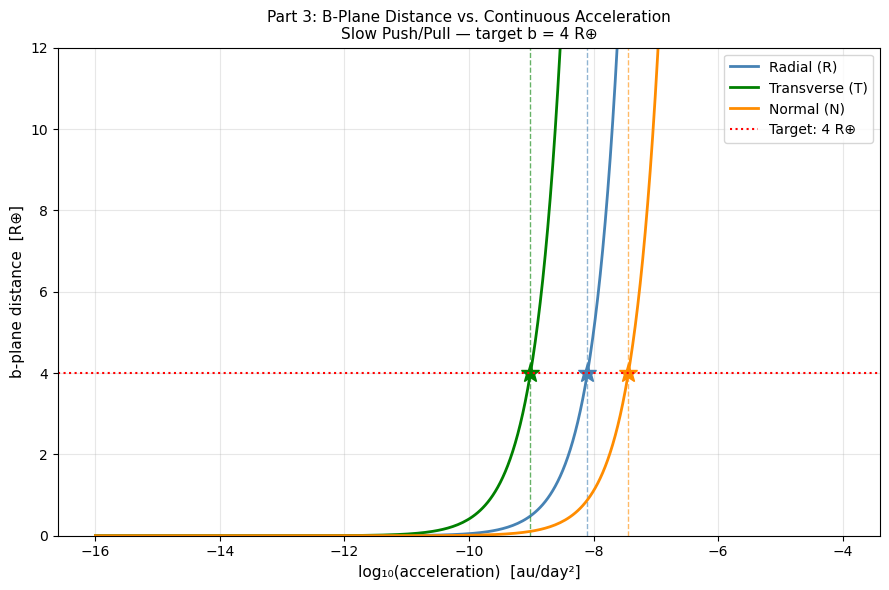

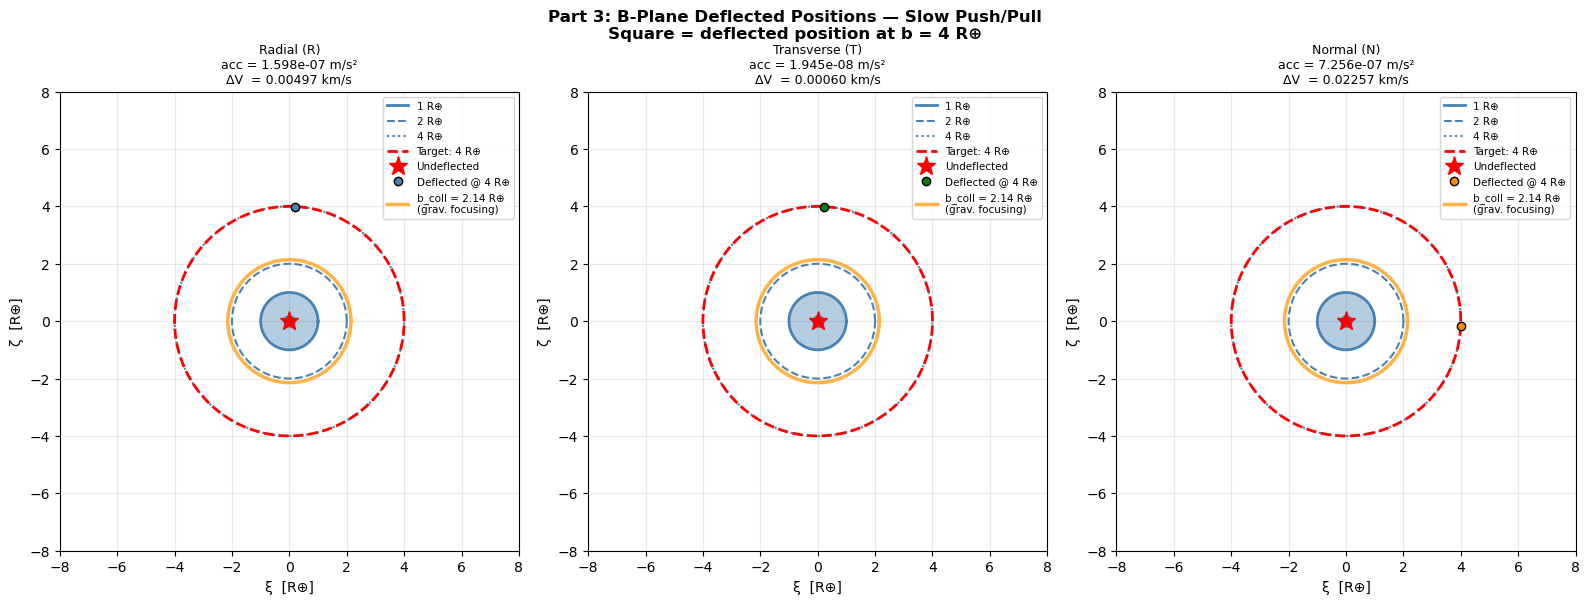


Part 3 done.


In [13]:
"""
AE 498 HW2 — Part 3: Gauss Planetary Equations (Slow Push/Pull)
----------------------------------------------------------------
Find the minimum continuous acceleration (and total ΔV) needed to
deflect FI2026 to at least 4 R⊕ on the b-plane.
Tested for Radial (R), Transverse (T), and Normal (N) directions.
"""

from scipy.optimize import brentq
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GAUSS PLANETARY EQUATIONS  (RTN perturbation)
# ============================================================
def gauss_rhs(a, e, i, om, Om, f, Fr, Ft, Fn):
    """
    Time derivatives of (a, e, i, om, Om) under RTN acceleration.
    Standard Gauss Variational Equations.

    Fr : radial acceleration      (away from Sun)
    Ft : transverse acceleration  (along velocity)
    Fn : normal acceleration      (out of orbital plane)
    """
    
    p  = a * (1 - e**2)
    r  = p / (1 + e * np.cos(f))
    h  = np.sqrt(mu_sun * p)
    b  = a * np.sqrt(1 - e**2)        # semi-minor axis
    n  = np.sqrt(mu_sun / a**3)        # mean motion
    u  = om + f                        # argument of latitude

    da  = (2 * a**2 / h) * (e * np.sin(f) * Fr + (p / r) * Ft)
    de  = (p * np.sin(f) * Fr + ((p + r) * np.cos(f) + r * e) * Ft) / h
    di  = r * np.cos(u) / h * Fn
    dOm = r * np.sin(u) / (h * np.sin(i)) * Fn
    dom = ((-p * np.cos(f) * Fr + (p + r) * np.sin(f) * Ft) / (h * e)) \
          - (r * np.sin(u) * np.cos(i) / (h * np.sin(i))) * Fn
    dM  = n + (b / (a * h * e)) * ((p * np.cos(f) - 2 * r * e) * Fr
                                  - (p + r) * np.sin(f) * Ft)

    return da, de, di, dom, dOm, dM


def integrate_gauss(elem0, acc_RTN, t_total, dt=0.5):
    """
    Euler-integrate Gauss equations for t_total days under
    constant RTN acceleration acc_RTN = (Fr, Ft, Fn) [AU/day²].
    Returns final element dict (with 'a' key).
    Returns None if orbit becomes invalid.
    """
    a  = get_semimajor(elem0['q'], elem0['e'])
    e  = elem0['e'];   i  = elem0['i']
    om = elem0['omega']; Om = elem0['Omega']
    M  = elem0['M']
    Fr, Ft, Fn = acc_RTN

    t = 0.0
    while t < t_total:
        step = min(dt, t_total - t)
        n    = np.sqrt(mu_sun / a**3)
        f    = M_to_f(M, e)
        da, de, di, dom, dOm, dM = gauss_rhs(a, e, i, om, Om, f, Fr, Ft, Fn)
        a  += da * step  
        e  += de * step
        i  += di * step
        om += dom * step
        Om += dOm * step
        M   = (M + dM * step) % (2 * np.pi)
        t  += step

        if a <= 0 or e >= 1 or e < 0:
            return None

    return dict(a=a, e=e, i=i, omega=om, Omega=Om, M=M)


def b_after_deflection(elem_defl, t_total):
    """
    Given deflected elements at epoch, propagate to t_total and
    compute b-plane vs Earth.
    elem_defl has 'a' key.
    """
    f_enc = M_to_f(elem_defl['M'], elem_defl['e'])
    r_ast, v_ast = state_vec(elem_defl['a'], elem_defl['e'], elem_defl['i'],
                              elem_defl['omega'], elem_defl['Omega'], f_enc)
    r_e, v_e = earth_state(t_total)
    b, xi, zeta, _, _ = bplane(r_ast, v_ast, r_e, v_e)
    return b, xi, zeta


def earth_state(t_days):
    """Earth inertial (r, v) at epoch + t_days."""
    a_e = get_semimajor(elem_earth['q'], elem_earth['e'])
    M_e = propagate_M(elem_earth['M'], a_e, t_days)
    f_e = M_to_f(M_e, elem_earth['e'])
    return state_vec(a_e, elem_earth['e'], elem_earth['i'],
                     elem_earth['omega'], elem_earth['Omega'], f_e)


# ============================================================
# SETUP
# ============================================================
t_impact  = 360.00059739141113   # days (from Part 1)
target_b  = 4.0 * R_earth        # AU  — 4 Earth radii

dir_labels = ['Radial (R)',  'Transverse (T)', 'Normal (N)']
dir_RTN    = [(1, 0, 0),     (0, 1, 0),         (0, 0, 1)]

# ============================================================
# FIND MINIMUM ACCELERATION FOR EACH DIRECTION
# ============================================================
print("=" * 60)
print("Part 3: Gauss Slow Push/Pull — Minimum ΔV to reach 4 R⊕")
print("=" * 60)

results = {}

for label, (Fr_hat, Ft_hat, Fn_hat) in zip(dir_labels, dir_RTN):

    def b_of_acc(log_acc):
        """Return b (AU) for a given log10(acceleration)."""
        acc = 10**log_acc
        ed  = integrate_gauss(elem_fi,
                               (Fr_hat * acc, Ft_hat * acc, Fn_hat * acc),
                               t_impact, dt=0.5)
        if ed is None:
            return np.nan
        b, _, _ = b_after_deflection(ed, t_impact)
        return b

    # Coarse scan over log10(acc) to find sign change
    log_range = np.linspace(-16, -4, 300)
    b_vals    = np.array([b_of_acc(la) for la in log_range])
    valid     = np.isfinite(b_vals)
    lv, bv    = log_range[valid], b_vals[valid]

    sign_changes = np.where(np.diff(np.sign(bv - target_b)))[0]

    if len(sign_changes) == 0:
        print(f"  {label:20s}: no solution found")
        results[label] = None
        continue

    # Bisect on first sign change
    idx    = sign_changes[0]
    log_sol = brentq(lambda la: b_of_acc(la) - target_b,
                     lv[idx], lv[idx + 1], xtol=1e-12)

    acc_sol  = 10**log_sol                          # AU/day²
    acc_ms2  = acc_sol * AU_KM * 1e3 / DAY_S**2    # m/s²
    dv_kms   = acc_sol * t_impact * AU_KM / DAY_S  # km/s  (acc × time)

    results[label] = dict(
        acc_AU  = acc_sol,
        acc_ms2 = acc_ms2,
        dv_kms  = dv_kms,
        Fr = Fr_hat * acc_sol,
        Ft = Ft_hat * acc_sol,
        Fn = Fn_hat * acc_sol,
        log_range = lv,
        b_vals    = bv,
    )

    print(f"\n  {label}")
    print(f"    Acceleration = {acc_ms2:.4e} m/s²")
    print(f"    Total ΔV     = {dv_kms:.6f} km/s  ({dv_kms*1e3:.4f} m/s)")

# Summary table
print("\n" + "-" * 60)
print(f"  {'Direction':<22} {'acc [m/s²]':>14}  {'ΔV [km/s]':>12}")
print("-" * 60)
for label in dir_labels:
    r = results[label]
    if r:
        print(f"  {label:<22} {r['acc_ms2']:>14.4e}  {r['dv_kms']:>12.6f}")
    else:
        print(f"  {label:<22} {'N/A':>14}  {'N/A':>12}")

best = min((l for l in dir_labels if results[l]),
           key=lambda l: results[l]['dv_kms'])
print(f"\n  Most effective direction: {best}")


# ============================================================
# FIGURE 1: b vs acceleration for each direction
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

colors = {'Radial (R)': 'steelblue', 'Transverse (T)': 'green', 'Normal (N)': 'darkorange'}

for label in dir_labels:
    r = results[label]
    if r is None:
        continue
    ax.plot(r['log_range'], r['b_vals'] / R_earth,
            lw=2, color=colors[label], label=label)
    # Mark solution point
    ax.axvline(np.log10(r['acc_AU']), color=colors[label],
               ls='--', lw=1, alpha=0.6)
    ax.plot(np.log10(r['acc_AU']), target_b / R_earth,
            '*', ms=14, color=colors[label])

ax.axhline(target_b / R_earth, color='red', lw=1.5, ls=':', label='Target: 4 R⊕')
ax.set_xlabel('log₁₀(acceleration)  [au/day²]', fontsize=11)
ax.set_ylabel('b-plane distance  [R⊕]', fontsize=11)
ax.set_title('Part 3: B-Plane Distance vs. Continuous Acceleration\n'
             'Slow Push/Pull — target b = 4 R⊕', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 12)
fig.tight_layout()

import os
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else '.'
fig.savefig(os.path.join(script_dir, 'hw2_part3_b_vs_acc.png'), dpi=160, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: Deflection tracks on the b-plane
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
theta_arr = np.linspace(0, 2 * np.pi, 400)

a_fi   = get_semimajor(elem_fi['q'], elem_fi['e'])
a_e    = get_semimajor(elem_earth['q'], elem_earth['e'])

# Get position at impact point (from Part 2)
M_fi_0 = propagate_M(elem_fi['M'],    a_fi, t_impact)
M_e_0  = propagate_M(elem_earth['M'], a_e,  t_impact)
r_fi0, _ = state_vec(a_fi, elem_fi['e'], elem_fi['i'],
                          elem_fi['omega'], elem_fi['Omega'], M_to_f(M_fi_0, elem_fi['e']))
r_e0,  _  = state_vec(a_e,  elem_earth['e'], elem_earth['i'],
                          elem_earth['omega'], elem_earth['Omega'], M_to_f(M_e_0, elem_earth['e']))

# Get velocity at impact point (from Part 2)
M_fi_0_minus = propagate_M(elem_fi['M'],    a_fi, t_minus)
M_e_0_minus  = propagate_M(elem_earth['M'], a_e,  t_minus)
_, v_fi0 = state_vec(a_fi, elem_fi['e'], elem_fi['i'],
                          elem_fi['omega'], elem_fi['Omega'], M_to_f(M_fi_0_minus, elem_fi['e']))
_,  v_e0  = state_vec(a_e,  elem_earth['e'], elem_earth['i'],
                          elem_earth['omega'], elem_earth['Omega'], M_to_f(M_e_0_minus, elem_earth['e']))


_, xi_impact, zeta_impact, _, _ = bplane(r_fi0, v_fi0, r_e0, v_e0)
xi_imp_Re    = xi_impact    * AU_KM / (6371.0)
zeta_imp_Re  = zeta_impact  * AU_KM / (6371.0)

R_e_km = 6371.0
for ax, label, (Fr_hat, Ft_hat, Fn_hat) in zip(axes, dir_labels, dir_RTN):
    r = results[label]

    # Reference circles
    for nr, ls, lw in [(1,'-',2),(2,'--',1.5),(4,':',1.5)]:
        ax.plot(nr*np.cos(theta_arr), nr*np.sin(theta_arr),
                ls=ls, lw=lw, color='steelblue', label=f'{nr} R⊕' if nr==1 else f'{nr} R⊕')

    # Target circle
    ax.plot(4*np.cos(theta_arr), 4*np.sin(theta_arr),
            ls='--', lw=2, color='red', label='Target: 4 R⊕')

    # Earth
    ax.add_patch(plt.Circle((0, 0), 1.0, color='steelblue', alpha=0.4, zorder=4))
    ax.plot(0, 0, 'o', color='steelblue', ms=8, zorder=5)

    # Undeflected impact point
    ax.plot(xi_imp_Re, zeta_imp_Re, 'r*', ms=14, zorder=6, label='Undeflected')

    # Plot only the deflected position at 4 R⊕
    if r is not None:
        ed_sol = integrate_gauss(elem_fi,
                                  (Fr_hat*r['acc_AU'], Ft_hat*r['acc_AU'], Fn_hat*r['acc_AU']),
                                  t_impact, dt=0.5)
        if ed_sol:
            _, xi_s, zeta_s = b_after_deflection(ed_sol, t_impact)
            ax.plot(xi_s * AU_KM / R_e_km, zeta_s * AU_KM / R_e_km,
                    '.', ms=12, color=colors[label], zorder=8,
                    markeredgecolor='black', label=f'Deflected @ 4 R⊕')
            ax.plot(b_coll_Re*np.cos(theta_arr), b_coll_Re*np.sin(theta_arr),
        '-', lw=2.5, color='#ffb347', label=f'b_coll = {b_coll_Re:.2f} R⊕\n(grav. focusing)')

        title = (f"{label}\n"
                 f"acc = {r['acc_ms2']:.3e} m/s²\n"
                 f"ΔV  = {r['dv_kms']:.5f} km/s")
    else:
        title = f"{label}\n(no solution)"

    ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect('equal')
    ax.set_xlabel('ξ  [R⊕]', fontsize=10)
    ax.set_ylabel('ζ  [R⊕]', fontsize=10)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Part 3: B-Plane Deflected Positions — Slow Push/Pull\n'
             'Square = deflected position at b = 4 R⊕',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(script_dir, 'hw2_part3_bplane_tracks.png'), dpi=160, bbox_inches='tight')
plt.show()
print("\nPart 3 done.")

Part 4: Kinetic Impact — Minimum DV to reach 4 R_earth

  Radial (R):

  Transverse (T):

  Normal (N):

  Radial (R) — top 5 lowest DV:
    Rank   t_apply [d]    DV [km/s]      DV [m/s]
    --------------------------------------------------
    1      184            0.001054       1.0539
    2      185            0.001054       1.0539
    3      183            0.001054       1.0543
    4      186            0.001054       1.0543
    5      182            0.001055       1.0551

  Transverse (T) — top 5 lowest DV:
    Rank   t_apply [d]    DV [km/s]      DV [m/s]
    --------------------------------------------------
    1      112            0.000288       0.2880
    2      113            0.000288       0.2880
    3      111            0.000288       0.2881
    4      114            0.000288       0.2881
    5      110            0.000288       0.2882

  Normal (N) — top 5 lowest DV:
    Rank   t_apply [d]    DV [km/s]      DV [m/s]
    -------------------------------------------------

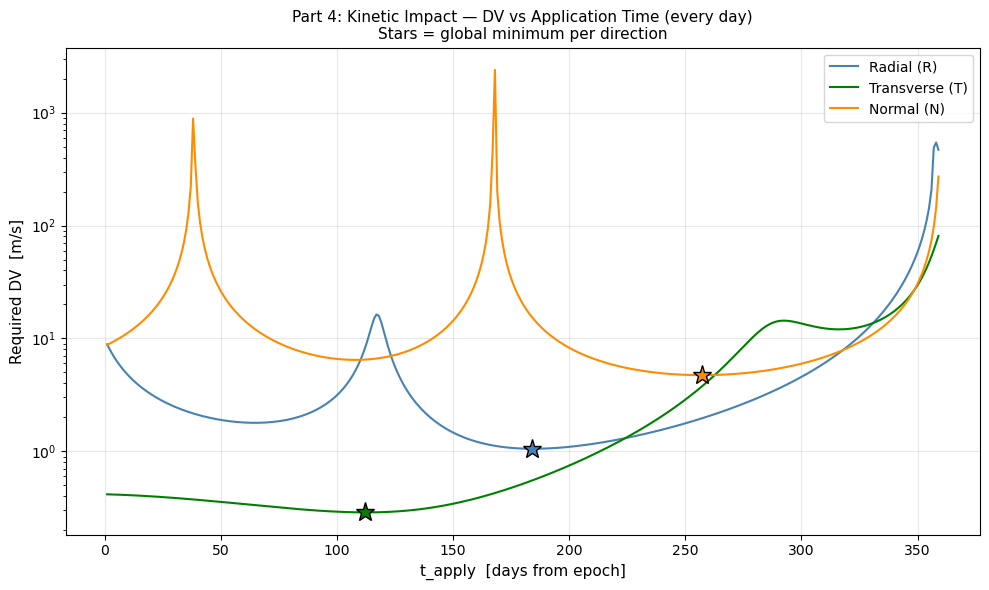

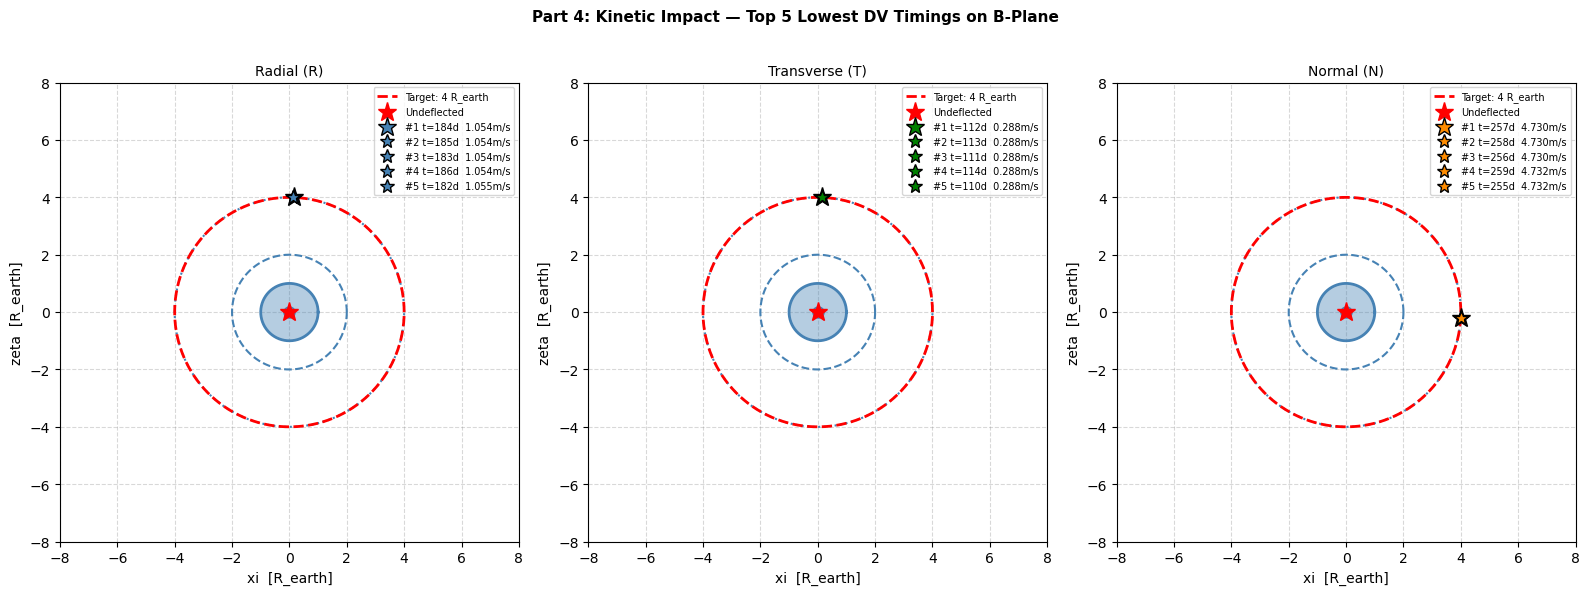


Part 4 done.


In [4]:
"""
AE 498 HW2 — Part 4: Kinetic Impact
-------------------------------------
Find the minimum instantaneous ΔV applied at time t_apply to deflect
FI2026 to at least 4 R⊕ on the b-plane.

Key difference from Part 3 (slow push/pull):
  - ΔV is INSTANTANEOUS — Gauss equations used as difference equations
  - Applied at t_apply, then asteroid coasts freely (Keplerian) to t_impact
  - Timing matters: earlier hit → more time to diverge → less ΔV needed

"""

# ============================================================
# KINETIC IMPACT: APPLY INSTANTANEOUS ΔV
# ============================================================



def apply_impulsive_dv(elem0, dv_RTN, t_apply):
    """
    Apply instantaneous ΔV at t_apply days from epoch.

    Steps:
      1. Propagate elements to t_apply using propagate_M()
      2. Apply Gauss equations as difference equations (single step)
         — only the perturbation part of dM (subtract n)
      3. Return deflected elements at t_apply

    Returns None if orbit becomes invalid.
    """
    a   = get_semimajor(elem0['q'], elem0['e'])
    e   = elem0['e'];   i  = elem0['i']
    om  = elem0['omega']; Om = elem0['Omega']
    M0  = elem0['M']

    # Step 1: propagate to t_apply (free Kepler)
    M_app = propagate_M(M0, a, t_apply)
    f_app = M_to_f(M_app, e)

    dVr, dVt, dVn = dv_RTN

    # Step 2: Gauss as difference equations (delta instead of d/dt x dt)
    da, de, di, dom, dOm, dM_full = gauss_rhs(a, e, i, om, Om, f_app, dVr, dVt, dVn)

    # For impulsive DV: subtract n from dM (only perturbation part, not drift)
    n  = np.sqrt(mu_sun / a**3)
    dM = dM_full - n

    a2  = a  + da
    e2  = e  + de
    i2  = i  + di
    om2 = om + dom
    Om2 = Om + dOm
    M2  = (M_app + dM) % (2 * np.pi)

    if a2 <= 0 or e2 >= 1 or e2 < 0:
        return None

    return dict(a=a2, e=e2, i=i2, omega=om2, Omega=Om2, M=M2)


def b_after_freecoast(elem_app, t_apply, t_impact):
    """
    Propagate deflected elements freely (pure Kepler, no thrust)
    from t_apply to t_impact, then compute b-plane vs Earth.
    """
    t_remain = t_impact - t_apply
    a = elem_app['a']

    M_enc = propagate_M(elem_app['M'], a, t_remain)
    f_enc = M_to_f(M_enc, elem_app['e'])

    r_ast, _ = state_vec(a, elem_app['e'], elem_app['i'],
                              elem_app['omega'], elem_app['Omega'], f_enc)
    r_e, _ = earth_state(t_impact)
    
    #get U_minus 2 days ago 
    M_enc_minus = propagate_M(elem_app['M'], a, t_remain-2)
    f_enc_minus = M_to_f(M_enc_minus, elem_app['e'])

    _, v_ast = state_vec(a, elem_app['e'], elem_app['i'],
                              elem_app['omega'], elem_app['Omega'], f_enc_minus)
    _, v_e = earth_state(t_impact-2)
    

    b, xi, zeta, _, _ = bplane(r_ast, v_ast, r_e, v_e)
    return b, xi, zeta


# ============================================================
# SETUP
# ============================================================
apply_times = np.arange(1, int(t_impact), 1)   # every day

print("=" * 65)
print("Part 4: Kinetic Impact — Minimum DV to reach 4 R_earth")
print("=" * 65)

colors_ki   = {'Radial (R)': 'steelblue',
               'Transverse (T)': 'green',
               'Normal (N)': 'darkorange'}

results_ki = {label: {} for label in dir_labels}

for label, (Fr_hat, Ft_hat, Fn_hat) in zip(dir_labels, dir_RTN):
    print(f"\n  {label}:")

    for t_app in apply_times:

        def b_of_dv(log_dv, Fr_hat=Fr_hat, Ft_hat=Ft_hat, Fn_hat=Fn_hat, t_app=t_app):
            dv = 10**log_dv
            ed = apply_impulsive_dv(elem_fi,
                                    (Fr_hat * dv, Ft_hat * dv, Fn_hat * dv),
                                    t_app)
            if ed is None:
                return np.nan
            b, _, _ = b_after_freecoast(ed, t_app, t_impact)
            return b

        # Coarse scan
        log_range = np.linspace(-10, -1, 200)
        b_vals    = np.array([b_of_dv(ld) for ld in log_range])
        valid     = np.isfinite(b_vals)
        lv, bv    = log_range[valid], b_vals[valid]

        sign_changes = np.where(np.diff(np.sign(bv - target_b)))[0]

        if len(sign_changes) == 0:
            results_ki[label][t_app] = None
            print(f"    t_apply = {t_app:3d} d:  no solution")
            continue

        idx     = sign_changes[0]
        log_sol = brentq(lambda ld: b_of_dv(ld) - target_b,
                         lv[idx], lv[idx + 1], xtol=1e-12)

        dv_sol_AU  = 10**log_sol
        dv_sol_kms = dv_sol_AU * AU_KM / DAY_S

        results_ki[label][t_app] = dict(
            dv_AU  = dv_sol_AU,
            dv_kms = dv_sol_kms,
            t_app  = t_app,
        )
        #print(f"    t_apply = {t_app:3d} d:  DV = {dv_sol_kms:.6f} km/s  ({dv_sol_kms*1e3:.3f} m/s)")

# ============================================================
# SUMMARY TABLE
# ============================================================
print()
for label in dir_labels:
    valid = {t: r for t, r in results_ki[label].items() if r is not None}
    top5  = sorted(valid.items(), key=lambda x: x[1]['dv_kms'])[:5]

    print(f"  {label} — top 5 lowest DV:")
    print(f"    {'Rank':<6} {'t_apply [d]':<14} {'DV [km/s]':<14} {'DV [m/s]'}")
    print(f"    {'-'*50}")
    for rank, (t, r) in enumerate(top5, 1):
        print(f"    {rank:<6} {t:<14.0f} {r['dv_kms']:<14.6f} {r['dv_kms']*1e3:.4f}")
    print()

# ============================================================
# FIGURE 1: DV vs application time
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for spine in ax.spines.values(): spine.set_color('black')
ax.tick_params(colors='black')
ax.grid(True, alpha=0.3)

for label in dir_labels:
    ts  = sorted(t for t, r in results_ki[label].items() if r is not None)
    dvs = [results_ki[label][t]['dv_kms'] * 1e3 for t in ts]
    ax.plot(ts, dvs, '-', color=colors_ki[label], lw=1.5, label=label)

    # Star on global best
    valid = {t: r for t, r in results_ki[label].items() if r is not None}
    best_t = min(valid, key=lambda t: valid[t]['dv_kms'])
    ax.plot(best_t, valid[best_t]['dv_kms']*1e3, '*', ms=14,
            color=colors_ki[label], markeredgecolor='black', zorder=6)

ax.set_xlabel('t_apply  [days from epoch]', fontsize=11)
ax.set_ylabel('Required DV  [m/s]', fontsize=11)
ax.set_title('Part 4: Kinetic Impact — DV vs Application Time (every day)\n'
             'Stars = global minimum per direction', fontsize=11)
ax.legend(fontsize=10)
ax.set_yscale('log')
fig.tight_layout()

import os
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else '.'
fig.savefig(os.path.join(script_dir, 'hw2_part4_dv_vs_timing.png'), dpi=160, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: B-plane — mark top 5 points per direction
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
theta_arr = np.linspace(0, 2 * np.pi, 400)

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values(): spine.set_color('black')
    ax.tick_params(colors='black')
    ax.grid(True, alpha=0.3, color='gray', linestyle='--')

for ax, label, (Fr_hat, Ft_hat, Fn_hat) in zip(axes, dir_labels, dir_RTN):

    for nr, ls, lw in [(1,'-',2),(2,'--',1.5),(4,':',1.5)]:
        ax.plot(nr*np.cos(theta_arr), nr*np.sin(theta_arr),
                ls=ls, lw=lw, color='steelblue')
    ax.plot(4*np.cos(theta_arr), 4*np.sin(theta_arr),
            ls='--', lw=2, color='red', label='Target: 4 R_earth')
    ax.add_patch(plt.Circle((0,0), 1.0, color='steelblue', alpha=0.4, zorder=4))
    ax.plot(0, 0, 'o', color='steelblue', ms=8, zorder=5)
    ax.plot(xi_imp_Re, zeta_imp_Re, 'r*', ms=14, zorder=6, label='Undeflected')

    valid = {t: r for t, r in results_ki[label].items() if r is not None}
    top5  = sorted(valid.items(), key=lambda x: x[1]['dv_kms'])[:5]

    for rank, (t_app, r) in enumerate(top5, 1):
        ed = apply_impulsive_dv(elem_fi,
                                (Fr_hat*r['dv_AU'], Ft_hat*r['dv_AU'], Fn_hat*r['dv_AU']),
                                t_app)
        if ed is None:
            continue
        _, xi_d, zeta_d = b_after_freecoast(ed, t_app, t_impact)
        ax.plot(xi_d * AU_KM / R_e_km, zeta_d * AU_KM / R_e_km,
                '*', ms=14 if rank == 1 else 10,
                color=colors_ki[label],
                markeredgecolor='black', zorder=7,
                label=f'#{rank} t={t_app}d  {r["dv_kms"]*1e3:.3f}m/s')

    ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect('equal')
    ax.set_xlabel('xi  [R_earth]', fontsize=10)
    ax.set_ylabel('zeta  [R_earth]', fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Part 4: Kinetic Impact — Top 5 Lowest DV Timings on B-Plane',
             fontsize=11, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(script_dir, 'hw2_part4_bplane_top5.png'), dpi=160, bbox_inches='tight')
plt.show()
print("\nPart 4 done.")

Part 5: Direction Effectiveness Comparison

  Slow Push/Pull (Part 3) — continuous acceleration over 360 days:
  Direction                  DV [m/s]   Ratio to best
  Radial (R)                   4.9706            8.22x
  Transverse (T)               0.6050            1.00x ← BEST
  Normal (N)                  22.5683           37.30x

  Kinetic Impact (Part 4) — instantaneous DV at optimal timing:
  Direction               t_apply [d]      DV [m/s]   Ratio to best
  Radial (R)                      184        1.0539            3.66x
  Transverse (T)                  112        0.2880            1.00x ← BEST
  Normal (N)                      257        4.7297           16.42x


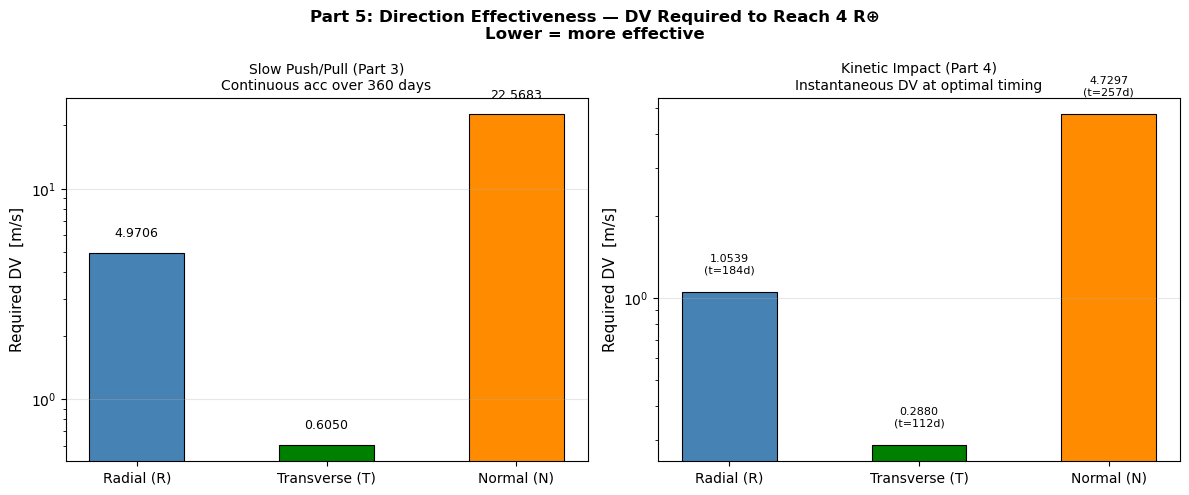

In [11]:
"""
AE 498 HW2 — Part 5: Direction Effectiveness Comparison
---------------------------------------------------------
Which acceleration/DV direction (R, T, N) is most effective?
Visualizations on the b-plane for both methods.

"""

# ============================================================
# PART 5: SUMMARY — DIRECTION EFFECTIVENESS
# ============================================================
print("=" * 65)
print("Part 5: Direction Effectiveness Comparison")
print("=" * 65)

# --- Collect Part 3 (slow push) numbers ---
p3_dv = {label: results[label]['dv_kms'] * 1e3
          for label in dir_labels if results[label]}   # m/s

# --- Collect Part 4 (kinetic impact) numbers at best timing ---
p4_best = {}
for label in dir_labels:
    valid = {t: r for t, r in results_ki[label].items() if r is not None}
    if valid:
        best_t = min(valid, key=lambda t: valid[t]['dv_kms'])
        p4_best[label] = dict(t_app=best_t,
                               dv_kms=valid[best_t]['dv_kms'],
                               dv_ms=valid[best_t]['dv_kms'] * 1e3)

print("\n  Slow Push/Pull (Part 3) — continuous acceleration over 360 days:")
print(f"  {'Direction':<22} {'DV [m/s]':>12}  {'Ratio to best':>14}")
best_p3 = min(p3_dv, key=p3_dv.get)
for label in dir_labels:
    ratio = p3_dv[label] / p3_dv[best_p3]
    marker = " ← BEST" if label == best_p3 else ""
    print(f"  {label:<22} {p3_dv[label]:>12.4f}  {ratio:>14.2f}x{marker}")

print("\n  Kinetic Impact (Part 4) — instantaneous DV at optimal timing:")
print(f"  {'Direction':<22} {'t_apply [d]':>12}  {'DV [m/s]':>12}  {'Ratio to best':>14}")
best_p4 = min(p4_best, key=lambda l: p4_best[l]['dv_ms'])
for label in dir_labels:
    r = p4_best[label]
    ratio = r['dv_ms'] / p4_best[best_p4]['dv_ms']
    marker = " ← BEST" if label == best_p4 else ""
    print(f"  {label:<22} {r['t_app']:>12.0f}  {r['dv_ms']:>12.4f}  {ratio:>14.2f}x{marker}")


# ============================================================
# FIGURE 1: Bar chart comparison — both methods, all directions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values(): spine.set_color('black')
    ax.tick_params(colors='black')
    ax.grid(True, alpha=0.3, axis='y')

bar_colors = ['steelblue', 'green', 'darkorange']
x = np.arange(len(dir_labels))
w = 0.5

# Left: slow push
dvs_p3 = [p3_dv[l] for l in dir_labels]
bars = axes[0].bar(x, dvs_p3, w, color=bar_colors, edgecolor='black', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(dir_labels, fontsize=10)
axes[0].set_ylabel('Required DV  [m/s]', fontsize=11)
axes[0].set_title('Slow Push/Pull (Part 3)\nContinuous acc over 360 days', fontsize=10)
axes[0].set_yscale('log')
for bar, dv in zip(bars, dvs_p3):
    axes[0].text(bar.get_x() + bar.get_width()/2, dv * 1.15,
                 f'{dv:.4f}', ha='center', va='bottom', fontsize=9)

# Right: kinetic impact
dvs_p4 = [p4_best[l]['dv_ms'] for l in dir_labels]
bars = axes[1].bar(x, dvs_p4, w, color=bar_colors, edgecolor='black', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(dir_labels, fontsize=10)
axes[1].set_ylabel('Required DV  [m/s]', fontsize=11)
axes[1].set_title('Kinetic Impact (Part 4)\nInstantaneous DV at optimal timing', fontsize=10)
axes[1].set_yscale('log')
for bar, dv, r in zip(bars, dvs_p4, [p4_best[l] for l in dir_labels]):
    axes[1].text(bar.get_x() + bar.get_width()/2, dv * 1.15,
                 f'{dv:.4f}\n(t={r["t_app"]}d)', ha='center', va='bottom', fontsize=8)

fig.suptitle('Part 5: Direction Effectiveness — DV Required to Reach 4 R⊕\n'
             'Lower = more effective', fontsize=12, fontweight='bold')
fig.tight_layout()

import os
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else '.'
fig.savefig(os.path.join(script_dir, 'hw2_part5_bar_comparison.png'), dpi=160, bbox_inches='tight')
plt.show()


Part 6: Valsecchi Circles
  U_n = 0.198046,  c = 1.7981 R⊕
  cos θ = 0.643838,  sin θ = 0.765161

  p:q      a0p [AU]     D [R⊕]           R [R⊕]
  --------------------------------------------------
  7:6      1.1082       -2.77            3.58
  6:5      1.1292       -3.03            3.89
  5:4      1.1604       -3.49            4.42
  4:3      1.2114       -4.55            5.59
  3:2      1.3104       -9.50            10.76
  2:1      1.5874       7.19             5.17


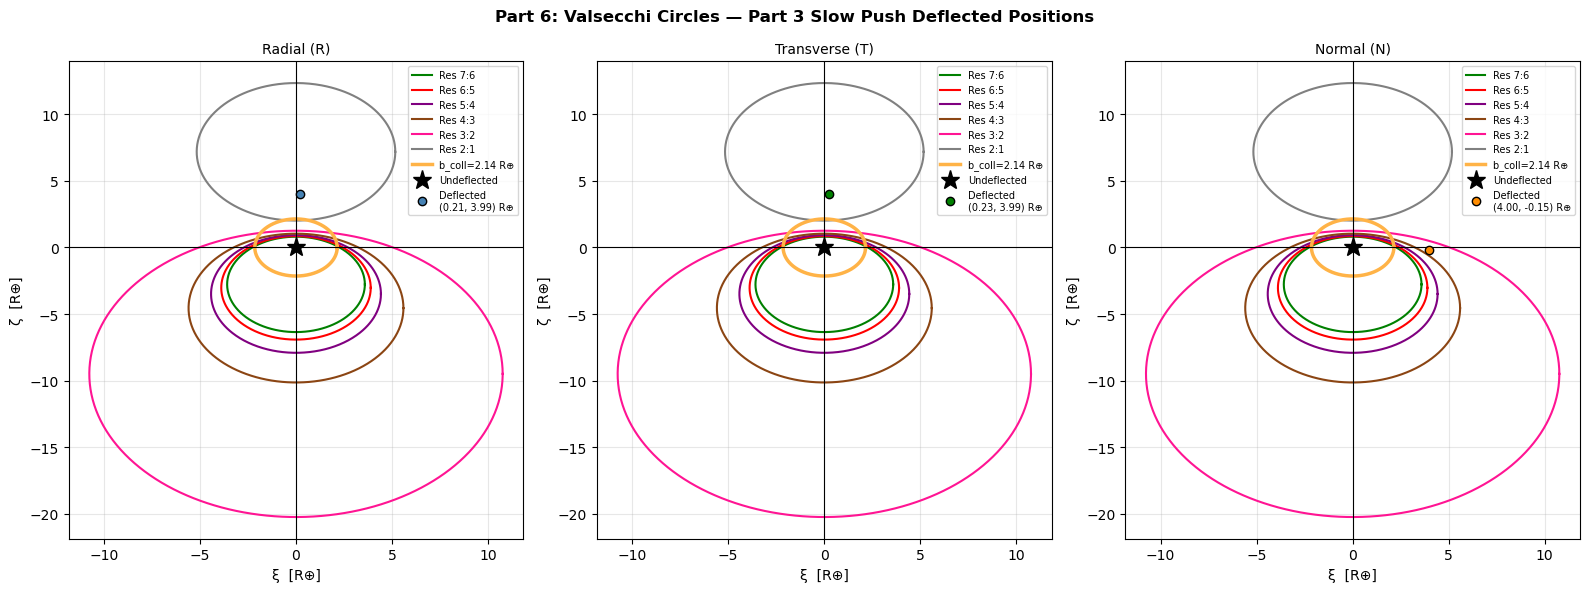

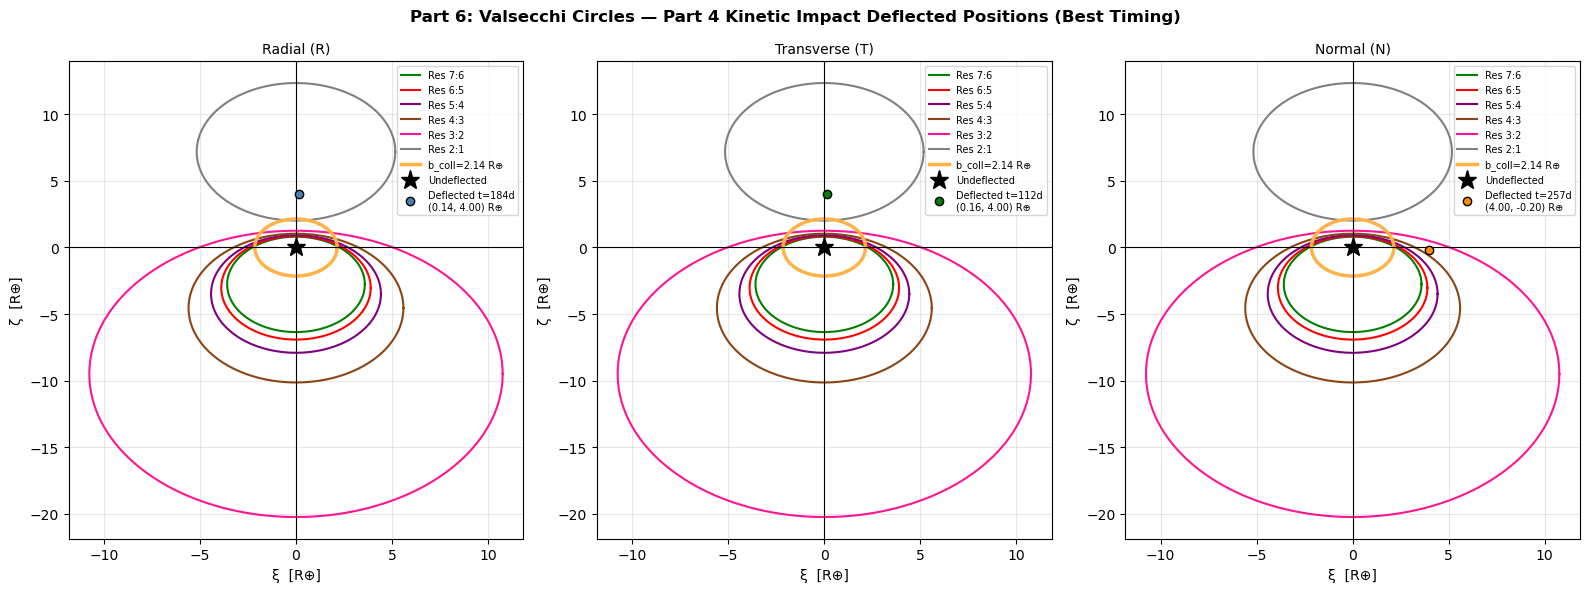


Part 6 done.


In [6]:
"""
AE 498 HW2 — Part 6: Valsecchi Circles + Deflected Positions
"""
# Earth mass in Valsecchi units (G=1, M_sun=1)
m_val = mu_earth / mu_sun
v_earth_AUday = 2 * np.pi / 365.25
U_n = U0 / v_earth_AUday
c = m_val / U_n**2
cos_th = np.clip(u_inf_vec[1] / U0, -1.0, 1.0)
sin_th = np.sqrt(1.0 - cos_th**2)

resonances = [(7,6),(6,5),(5,4),(4,3),(3,2),(2,1)]
vc_colors  = {(7,6):'green',(6,5):'red',(5,4):'purple',
              (4,3):'saddlebrown',(3,2):'deeppink',(2,1):'gray'}

print("=" * 65)
print("Part 6: Valsecchi Circles")
print("=" * 65)
print(f"  U_n = {U_n:.6f},  c = {c*AU_KM/R_e_km:.4f} R⊕")
print(f"  cos θ = {cos_th:.6f},  sin θ = {sin_th:.6f}\n")
print(f"  {'p:q':<8} {'a0p [AU]':<12} {'D [R⊕]':<16} {'R [R⊕]'}")
print(f"  {'-'*50}")

the = np.linspace(0, 2*np.pi, 500)

# Pre-compute Valsecchi circles once
vc_circles = []
for p, q in resonances:
    a_0_d    = (p/q)**(2.0/3.0)
    cos_th_d = np.clip((1.0 - U_n**2 - 1.0/a_0_d) / (2.0*U_n), -1.0, 1.0)
    sin_th_d = np.sqrt(1.0 - cos_th_d**2)
    denom    = cos_th_d - cos_th
    if abs(denom) < 1e-10:
        continue
    D = (c * sin_th  / denom) * AU_KM / R_e_km
    R = abs(c * sin_th_d / denom) * AU_KM / R_e_km
    print(f"  {p}:{q:<6} {a_0_d:<12.4f} {D:<16.2f} {R:.2f}")
    vc_circles.append((p, q, D, R))

dir_colors = {'Radial (R)': 'steelblue',
              'Transverse (T)': 'green',
              'Normal (N)': 'darkorange'}

def draw_base(ax, title):
    """Draw Valsecchi circles, b_coll, axes, undeflected point."""
    for p, q, D, R in vc_circles:
        ax.plot(R*np.cos(the), D + R*np.sin(the),
                color=vc_colors[(p,q)], lw=1.5, label=f"Res {p}:{q}")
    ax.plot(b_coll_Re*np.cos(the), b_coll_Re*np.sin(the),
            lw=2.5, color='#ffb347', label=f'b_coll={b_coll_Re:.2f} R⊕')
    ax.plot(xi0_km/R_e_km, zeta0_km/R_e_km,
            'k*', ms=14, zorder=10, label='Undeflected')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel("ξ  [R⊕]", fontsize=10)
    ax.set_ylabel("ζ  [R⊕]", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)

# ============================================================
# FIGURE 1: Part 3 — Slow Push, one subplot per direction
# ============================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 6))
fig1.suptitle("Part 6: Valsecchi Circles — Part 3 Slow Push Deflected Positions",
              fontsize=12, fontweight='bold')

for ax, label, (Fr_hat, Ft_hat, Fn_hat) in zip(axes1, dir_labels, dir_RTN):
    draw_base(ax, label)

    r = results[label]
    if r is not None:
        ed = integrate_gauss(elem_fi,
                             (Fr_hat*r['acc_AU'], Ft_hat*r['acc_AU'], Fn_hat*r['acc_AU']),
                             t_impact, dt=0.5)
        if ed is not None:
            _, xi_d, zeta_d = b_after_deflection(ed, t_impact)
            xi_re   = xi_d   * AU_KM / R_e_km
            zeta_re = zeta_d * AU_KM / R_e_km
            ax.plot(xi_re, zeta_re, '.', ms=12,
                    color=dir_colors[label], markeredgecolor='black',
                    zorder=11, label=f'Deflected\n({xi_re:.2f}, {zeta_re:.2f}) R⊕')

    ax.legend(fontsize=7, loc='upper right')

fig1.tight_layout()
fig1.savefig('hw2_part6_slowpush.png', dpi=160, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: Part 4 — Kinetic Impact (best timing), one subplot per direction
# ============================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6))
fig2.suptitle("Part 6: Valsecchi Circles — Part 4 Kinetic Impact Deflected Positions (Best Timing)",
              fontsize=12, fontweight='bold')

for ax, label, (Fr_hat, Ft_hat, Fn_hat) in zip(axes2, dir_labels, dir_RTN):
    draw_base(ax, label)

    valid = {t: r for t, r in results_ki[label].items() if r is not None}
    if valid:
        best_t = min(valid, key=lambda t: valid[t]['dv_kms'])
        r = valid[best_t]
        ed = apply_impulsive_dv(elem_fi,
                                (Fr_hat*r['dv_AU'], Ft_hat*r['dv_AU'], Fn_hat*r['dv_AU']),
                                best_t)
        if ed is not None:
            _, xi_d, zeta_d = b_after_freecoast(ed, best_t, t_impact)
            xi_re   = xi_d   * AU_KM / R_e_km
            zeta_re = zeta_d * AU_KM / R_e_km
            ax.plot(xi_re, zeta_re, '.', ms=12,
                    color=dir_colors[label], markeredgecolor='black',
                    zorder=11, label=f'Deflected t={best_t}d\n({xi_re:.2f}, {zeta_re:.2f}) R⊕')

    ax.legend(fontsize=7, loc='upper right')

fig2.tight_layout()
fig2.savefig('hw2_part6_kinetic.png', dpi=160, bbox_inches='tight')
plt.show()

print("\nPart 6 done.")